
## <font color='green'>Image Classification</font>
## <font color='green'>Satellite Image Classification with Deep Learning</font>

In [1]:
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 18.4 MB/s eta 0:00:00


In [2]:
# Imports
import os
import time
import shutil
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import sklearn
from sklearn.metrics import confusion_matrix

In [3]:
%reload_ext watermark
%watermark -a "Silmara Basso" -d -t -p torch,torchvision,sklearn,seaborn,matplotlib

Author: Silmara Basso

Date/Time: 2026-05-27 20:21:45

torch      : 2.8.0+cu126
torchvision: 0.23.0+cu126
sklearn    : 1.6.1
seaborn    : 0.13.2
matplotlib : 3.10.0



In [4]:
# Check the GPU model (if available)
if torch.cuda.is_available():
    print('Number of GPUs:', torch.cuda.device_count())
    print('GPU Model:', torch.cuda.get_device_name(0))
    print('Total Memory [GB] of GPU:',torch.cuda.get_device_properties(0).total_memory / 1e9)

Number of GPUs: 1
GPU Model: Tesla T4
Total Memory [GB] of GPU: 15.637086208


In [5]:
# Reset GPU memory 
from numba import cuda
device = cuda.get_current_device()
device.reset()

## Organizing Images on Disk

In [6]:
# Delete the folders (if they exist).
try:
    shutil.rmtree('EuroSAT_RGB')
    shutil.rmtree('__MACOSX')
    shutil.rmtree('training_images')
    shutil.rmtree('test_images')
except Exception as e:
    print(f"The folders either do not exist or have already been deleted!")

The folders either do not exist or have already been deleted!


In [8]:
import zipfile
from google.colab import drive

drive.mount('/content/drive')

with zipfile.ZipFile('/content/drive/MyDrive/data/EuroSAT_RGB.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Concluído!")

Mounted at /content/drive
Concluído!


In [9]:
import os

# Ver diretório atual
print("Diretório atual:", os.getcwd())

# Listar tudo em /content
print("\nConteúdo de /content:")
for item in os.listdir('/content'):
    print(" ", item)

# Ver se a pasta data existe
if os.path.exists('/content/EuroSAT_RGB'):
    print("\nConteúdo de /content/EuroSAT_RGB:")
    for item in os.listdir('/content/EuroSAT_RGB'):
        print(" ", item)
else:
    print("\nPasta 'EuroSAT_RGB' não existe em /content")

Diretório atual: /content

Conteúdo de /content:
  .config
  EuroSAT_RGB
  __MACOSX
  drive
  sample_data

Conteúdo de /content/EuroSAT_RGB:
  PermanentCrop
  .DS_Store
  Industrial
  River
  Residential
  SeaLake
  Highway
  AnnualCrop
  Pasture
  HerbaceousVegetation
  Forest


In [10]:
# Crie as pastas
os.mkdir('training_images')
os.mkdir('test_images')


In [11]:
# Define the source of the images
images_source = 'EuroSAT_RGB'

In [12]:
# Define the destination folders
training_destination = 'training_images'
test_destination = 'test_images'

## Automating Image Separation

In [13]:
# Class variable and dictionary to associate the class of the image with its respective file path in the 'class_dict' dictionary.
image_class = 0
class_dict = {}

In [14]:
# Creates the variable to manipulate the images and the list of files in the source folder.
files = os.listdir(images_source)
files.sort()

In [15]:
files

['.DS_Store',
 'AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

In [16]:
# Iterates over all files (or directories) in the 'files' list and processes each one that is not a hidden file (i.e., does not start with a dot).
for caminho_arquivo in files:

    # Checks if the file path does not start with a dot, which indicates that it is not a hidden file. If it is a hidden file, it will be ignored and the loop will move to the next iteration.
    if caminho_arquivo[0] != '.':

        # Lists all images in the specified directory
        images = os.listdir(images_source + '/' + caminho_arquivo)

        # Calculates the size of the sample for the training set (80% of the total number of images)
        sample_size = int(len(images) * 0.8)

        # Creates an empty list to store the names of the images that will be used for training
        train = []

        # Define the final destination for the training images
        final_dest = training_destination + '/' + str(image_class)

        # Create a new directory for the training images
        os.mkdir(final_dest)

        # Randomly selects a sample of images for training and iterates over each selected image
        for file_name in random.sample(images, sample_size):

            # Copies the selected image from the source directory to the final destination directory for training images
            shutil.copy2(os.path.join(images_source, caminho_arquivo, file_name), final_dest)

            # Appends the name of the selected image to the 'train' list, which keeps track of the images that have been selected for training
            train.append(file_name)

        # Calculates the list of test images by taking the set difference between the total images and the training images. This ensures that the test set contains only images that were not used for training.
        test_images = list(set(images) - set(train))

        # Defines the final destination for the test images
        final_dest = test_destination + '/' + str(image_class)

        # Creates a new directory for the test images
        os.mkdir(final_dest)

        # Copy all test images to the destination directory
        for test_image in test_images:
            shutil.copy2(os.path.join(images_source, caminho_arquivo, test_image), final_dest)

        # Associates the class of the image with its respective file path in the 'class_dict' dictionary, where the key is the class identifier (image_class) and the value is the file path (caminho_arquivo).
        class_dict[image_class] = caminho_arquivo

        image_class += 1

## Pre-processing and creation of dataloaders

In [17]:
# Data transformations
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [18]:
# Training dataset
dataset_training = torchvision.datasets.ImageFolder(root = 'training_images', transform = transform)

In [19]:
# Training dataloader
dl_training = torch.utils.data.DataLoader(dataset_training, batch_size = 64, shuffle = True, num_workers = 2)

In [20]:
# Test dataset
dataset_test = torchvision.datasets.ImageFolder(root = 'test_images', transform = transform)

In [21]:
# Test dataloader
dl_test = torch.utils.data.DataLoader(dataset_test, batch_size = 1, shuffle = True, num_workers = 2)

## Viewing the Images

In [22]:
# Function to view images
def imshow(img):

    # Loads and normalizes the image
    img = img / 2 + 0.5

    # Converts the image to a numpy array
    npimg = img.numpy()

    # Displays the image
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [23]:
# Get a batch of images
dataiter = iter(dl_training)
images, labels = next(dataiter)

In [24]:
mapping = { 0:'AnnualCrop',
            1:'Forest',
            2:'HerbaceousVegetation',
            3:'Highway',
            4:'Industrial',
            5:'Pasture',
            6:'PermanentCrop',
            7:'Residential',
            8:'River',
            9:'SeaLake'}

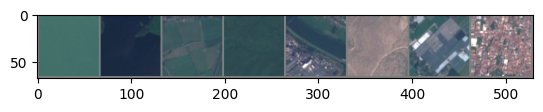

Labels: 9 9 5 1 8 2 4 7


In [25]:
# Show the images and their respective labels
imshow(torchvision.utils.make_grid(images[:8]))
print('Labels:', ' '.join('%d' % labels[j] for j in range(8)))

## Modeling - Building the Deep Learning Model

In [ ]:
# Defines a new model class called CNNNet, which inherits from nn.Module, a base class for all neural network modules in PyTorch.
class CNNNet(nn.Module):

    # Class constructor methode
    def __init__(self):

        # Calls the constructor of the parent class (nn.Module)
        super(CNNNet, self).__init__()

        # defines the first convolution layer with 3 input channels and 64 output channels
        # and a kernel size of 3x3
        self.conv1 = nn.Conv2d(3, 64, 3, 1)

        # Defines the second convolution layer with 64 input channels, 128 output channels
        # and a kernel size of 3x3
        self.conv2 = nn.Conv2d(64, 128, 3, 1)

        # defines the third convolution layer with 128 input channels, 256 output channels
        # and a kernel size of 3x3
        self.conv3 = nn.Conv2d(128, 256, 3, 1)

        # Define the first dropout layer with a probability of 0.25
        self.dropout1 = nn.Dropout(0.25)

        # Define the second dropout layer with a probability of 0.5
        self.dropout2 = nn.Dropout(0.5)

        # Define the first fully connected layer (Dense) that maps from 215296 to 2048 neurons
        self.fc1 = nn.Linear(215296, 2048)

        # Define the second fully connected layer that maps from 2048 to 512 neurons
        self.fc2 = nn.Linear(2048, 512)

        # Define the third fully connected layer that maps from 512 to 128 neurons
        self.fc3 = nn.Linear(512, 128)

        # Define the fourth fully connected layer that maps from 128 to 10 neurons
        self.fc4 = nn.Linear(128, 10)

    # Define the forward method for the forward pass
    def forward(self, x):

        # Apply the first convolutional layer
        x = self.conv1(x)

        # Apply the ReLU activation function
        x = F.relu(x)

        # Apply the second convolutional layer
        x = self.conv2(x)

        # Apply the ReLU activation function
        x = F.relu(x)

        # Apply the third convolutional layer
        x = self.conv3(x)

        # Apply the ReLU activation function
        x = F.relu(x)

        # Apply max pooling with a kernel of size 2x2
        x = F.max_pool2d(x, 2)

        # Apply the first dropout layer
        x = self.dropout1(x)

        # "Flatten" the tensor to prepare for the fully connected layer
        x = torch.flatten(x, 1)

        # Apply the first fully connected layer
        x = self.fc1(x)

        # Apply the ReLU activation function
        x = F.relu(x)

        # Apply the second dropout layer
        x = self.dropout2(x)

        # Apply the second fully connected layer
        x = self.fc2(x)

        # Apply the ReLU activation function
        x = F.relu(x)

        # Apply the third fully connected layer
        x = self.fc3(x)

        # Apply the ReLU activation function
        x = F.relu(x)

        # Apply the fourth fully connected layer
        x = self.fc4(x)

        # Returns the log-softmax of the resulting tensor along dimension 1 (commonly used for classification)
        return F.log_softmax(x, dim = 1)

In [ ]:
# Create the model
model = CNNNet()

In [28]:
print(model)

DSANet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=215296, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)


In [29]:
# Define the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [30]:
# Move the model to the specified device (GPU or CPU)
model.to(device)

DSANet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=215296, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)

## Selecting the Error Function

In [31]:
# Error function
criterion = nn.CrossEntropyLoss()

## Selecting the Optimizer

In [32]:
# optimizer
optimizer = optim.Adam(model.parameters())

## Model Training

In [33]:
# Number of epochs

# Increase the number of epochs for a more accurate model
# Decrease the number of epochs for faster training
# epochs_num = 30
epochs_num = 5

In [37]:
# Test iteration
testiter = iter(dl_test)

In [38]:
%%time
print('Training Started!')

# Iterate over the number of epochs
for epoch in range(epochs_num):

    # Initializes the variable that accumulates the loss over the period
    running_loss = 0.0

    # Initializes a counter for the batches
    i = 0

    # Iterates over the training data with a progress bar (tqdm)
    for data in (pbar := tqdm(dl_training)):
        # Updates the description of the progress bar to show the current epoch
        pbar.set_description(f"\nEpoch {epoch}")

        # Unpacks the batch of data into inputs and labels
        inputs, labels = data

        # Move the entries and labels to the correct device (CPU or GPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zeros the gradients of the optimizer to prepare for the backward pass
        optimizer.zero_grad()

        # It performs the forward transmission through the neural network
        outputs = model(inputs)

        # Calculate the loss using the defined criteria
        loss = criterion(outputs, labels)

        # Performs the backward step to calculate the gradients
        loss.backward()

        # Update the neural network weights using the optimizer
        optimizer.step()

        # Updates the accumulated loss value
        running_loss += loss.item()

        # Initializes counters for the number of correct predictions and the total number of samples
        total_correct = 0
        total_samples = 0

        # Every 100 batches, it evaluates the model on a batch of test images and prints the predictions
        if i % 100 == 0:

            # Disables gradient calculation to save memory and processing time
            with torch.no_grad():

                # Get a batch of test images and labels
                test_images, test_labels = next(testiter)
                test_images, test_labels = test_images.to(device), test_labels.to(device)

                # Gets the outputs of the model for the test images
                test_outputs = model(test_images[:8])

                # Gets the predictions for the 8 images
                _, predicted = torch.max(test_outputs, 1)

        # Increases the batch counter
        i += 1

    # Displays the average loss for the period
    print(f"Epoch {epoch}, Loss: {running_loss / (i)}")

print('Training Completed!')

Training Started!


Epoch 0: 100%|██████████| 338/338 [01:33<00:00,  3.60it/s]


Epoch 0, Loss: 1.1363814924595623


Epoch 1: 100%|██████████| 338/338 [01:36<00:00,  3.51it/s]


Epoch 1, Loss: 0.6857716323003261


...

Epoch 2, Loss: 0.4714614022412949


Epoch 3: 100%|██████████| 338/338 [01:37<00:00,  3.46it/s]


Epoch 3, Loss: 0.3181941315267213


Epoch 4: 100%|██████████| 338/338 [01:37<00:00,  3.45it/s]

Epoch 4, Loss: 0.20663655360267888
Training Completed!
CPU times: user 7min 33s, sys: 4.01 s, total: 7min 37s
Wall time: 8min 3s


## Model Evaluation

In [39]:
# Initializes the counters for the number of correct predictions and the total number of samples
total_correct = 0
total_samples = 0

In [40]:
# Sets the model to evaluation mode, which is important for layers like dropout and batch normalization to behave correctly during evaluation
model.eval()

# 
with torch.no_grad():

    # Iterates over the test data with a progress bar (tqdm)
    for data in (pbar := tqdm(dl_test)):

        # Updates the description of the progress bar to indicate that the model is being evaluated
        pbar.set_description(f"Evaluating the Model.")

        # Unpacks the batch of data into inputs and labels
        inputs, labels = data

        # Move the entries and labels to the correct device (CPU or GPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Gets the outputs of the model for the test images
        outputs = model(inputs)

        # Gets the predicted class (index of the maximum value) for each entry in the batch
        _, predicted = torch.max(outputs.data, 1)

        # Increment the total number of samples by the number of labels in the current batch
        total_samples += labels.size(0)

        # Increment the total number of correct predictions by the number of correct predictions in the current batch
        total_correct +=  (predicted == labels).sum().item()

Evaluating the Model.: 100%|██████████| 5400/5400 [00:57<00:00, 93.68it/s]


In [41]:
# Calculate the accuracy
accuracy = total_correct/total_samples
print(accuracy)

0.8464814814814815


## Deployment and Use of the Model

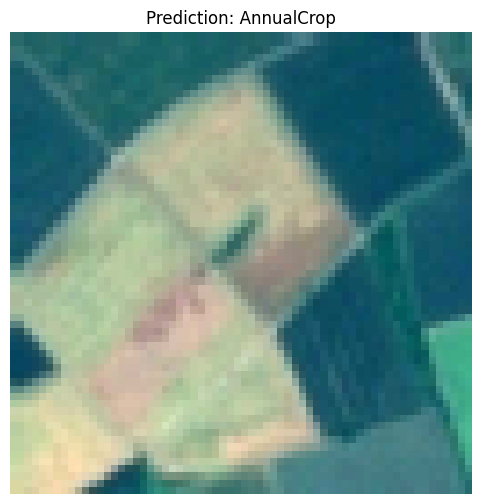

In [42]:
# Put the model into evaluation mode
with torch.no_grad():

    # Get the first batch of data
    data_iter = iter(dl_test)
    data = next(data_iter)

    # Unpacks the batch of data into inputs and labels
    inputs, _ = data

    # Selects the first image from the batch and adds a batch dimension (unsqueeze) to make it compatible with the model's expected input shape
    imagem = inputs[0].unsqueeze(0)

    # Move the image to the same device as the model
    imagem = imagem.to(device)

    # Gets the prediction of the model for this image
    outputs = model(imagem)

    # Gets the predicted class (index of the maximum value) for the image
    _, predicted = torch.max(outputs, 1)

    # Converts the image to numpy format for visualization
    # Move the image back to CPU and convert to numpy
    imagem_numpy = imagem.cpu().numpy()[0]

    # The images are usually in the format [C, H, W], so you need to reorder them to [H, W, C] for viewing
    # This also depends on the type of image data; normalization or range adjustment may be necessary for correct viewing
    imagem_numpy = np.transpose(imagem_numpy, (1, 2, 0))

    # Adjust the image channels if necessary (for example, if it is in grayscale or if normalization has been applied)
    if imagem_numpy.shape[2] == 1:  # Grayscale images
        imagem_numpy = np.squeeze(imagem_numpy, axis=2)
    elif imagem_numpy.shape[2] == 3:  # RGB images
        imagem_numpy = (imagem_numpy - imagem_numpy.min()) / (imagem_numpy.max() - imagem_numpy.min())  # Normalize to 0-1 if necessary

    plt.figure(figsize=(6, 6))
    plt.imshow(imagem_numpy)
    plt.title(f'Prediction: {mapping[predicted.item()]}')
    plt.axis('off')
    plt.show()

In [43]:
%watermark -a "silmarabasso" 

Author: silmarabasso



In [44]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.122+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



In [45]:
%watermark --iversions

google     : 2.0.3
matplotlib : 3.10.0
numba      : 0.60.0
numpy      : 2.0.2
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.8.0+cu126
torchvision: 0.23.0+cu126
tqdm       : 4.67.1

